<a href="https://colab.research.google.com/github/m7-code/Models/blob/main/x_ray.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
from torch import nn


torch.__version__


'2.9.0+cu128'

In [ ]:
# device-agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

!pip install -q torchvision tqdm

#zip file

In [ ]:
import zipfile
from pathlib import Path

# Your zip file path - UPDATE THIS
ZIP_FILE_PATH = '/content/drive/MyDrive/pneumonia _x_ray.zip'

# Extract location
EXTRACT_DIR = '/content/chest_xray'

# Extract
print("Extracting...")
with zipfile.ZipFile(ZIP_FILE_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

print("Done")
!ls -la {EXTRACT_DIR}

Extracting...
✓ Done
total 20
drwxr-xr-x 5 root root 4096 Feb 14 03:14 .
drwxr-xr-x 1 root root 4096 Feb 14 03:14 ..
drwxr-xr-x 4 root root 4096 Feb 14 03:14 test
drwxr-xr-x 4 root root 4096 Feb 14 03:14 train
drwxr-xr-x 4 root root 4096 Feb 14 03:14 val


In [ ]:
from pathlib import Path

# Set data paths
DATA_DIR = Path('/content/chest_xray')
TRAIN_DIR = DATA_DIR / 'train'
VAL_DIR = DATA_DIR / 'val'
TEST_DIR = DATA_DIR / 'test'

print(f"Train: {TRAIN_DIR.exists()}")
print(f"Val: {VAL_DIR.exists()}")
print(f"Test: {TEST_DIR.exists()}")

Train: True
Val: True
Test: True


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models
from PIL import Image
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import json
from datetime import datetime

# Checking GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: Tesla T4


In [ ]:
class ChestXRayDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = Path(root_dir)
        self.transform = transform
        self.images = []
        self.labels = []

        # NORMAL 0
        normal_dir = self.root_dir / "NORMAL"
        if normal_dir.exists():
            for img in normal_dir.iterdir():
                if img.suffix.lower() in ['.jpg', '.jpeg', '.png']:
                    self.images.append(img)
                    self.labels.append(0)

        # PNEUMONIA 1
        pneumonia_dir = self.root_dir / "PNEUMONIA"
        if pneumonia_dir.exists():
            for img in pneumonia_dir.iterdir():
                if img.suffix.lower() in ['.jpg', '.jpeg', '.png']:
                    self.images.append(img)
                    self.labels.append(1)

        print(f"{root_dir.name}: {len(self.images)} images (N:{self.labels.count(0)}, P:{self.labels.count(1)})")

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = self.images[idx]
        image = Image.open(img_path).convert("RGB")
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        return image, label

#Data Transforms

In [ ]:
IMAGE_SIZE = 224
BATCH_SIZE = 32

# Training transforms with augmentation
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Validation transforms no augmentation
val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print(" Transforms ready")

 Transforms ready


In [ ]:
# Creating datasets
train_dataset = ChestXRayDataset(TRAIN_DIR, transform=train_transform)
val_dataset = ChestXRayDataset(VAL_DIR, transform=val_transform)
test_dataset = ChestXRayDataset(TEST_DIR, transform=val_transform)

# Creating dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print("Dataloaders created")

train: 5216 images (N:1341, P:3875)
val: 16 images (N:8, P:8)
test: 624 images (N:234, P:390)
Dataloaders created


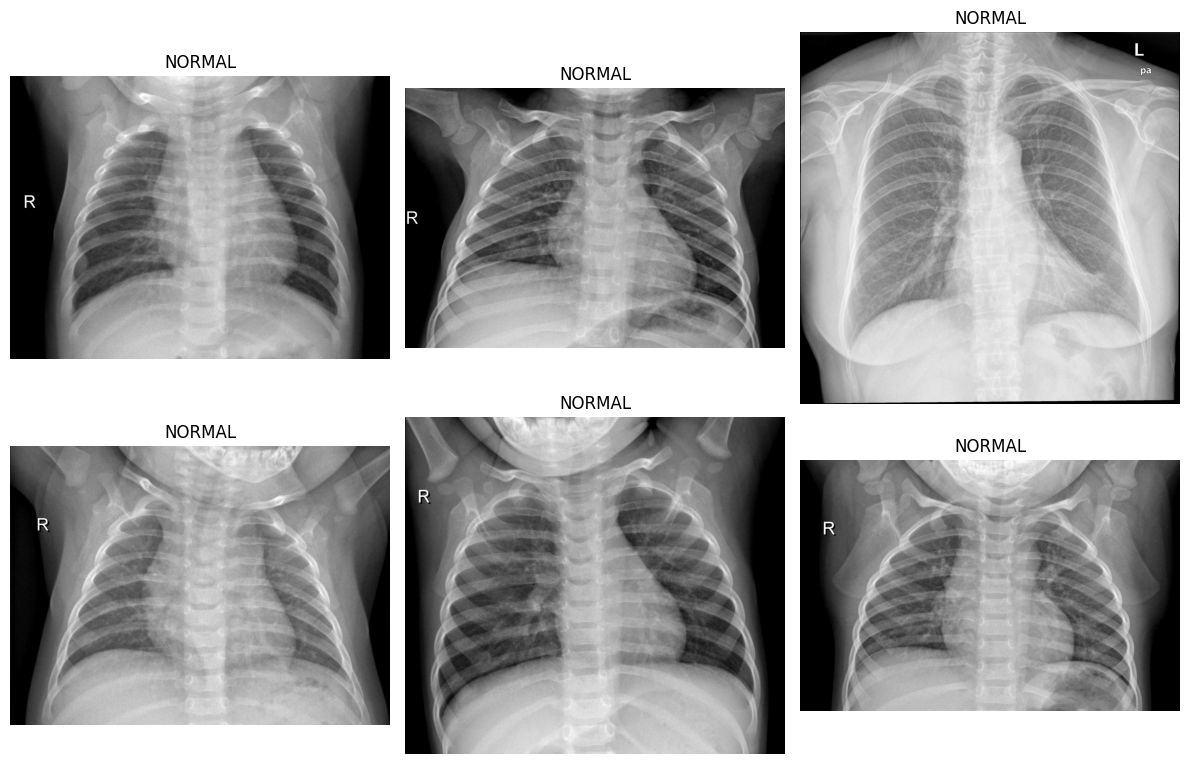

In [ ]:
#  images
def show_samples(dataset, n=6):
    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    axes = axes.flatten()
    class_names = ['NORMAL', 'PNEUMONIA']

    for i in range(n):
        img = Image.open(dataset.images[i])
        label = dataset.labels[i]
        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(class_names[label])
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

show_samples(train_dataset)

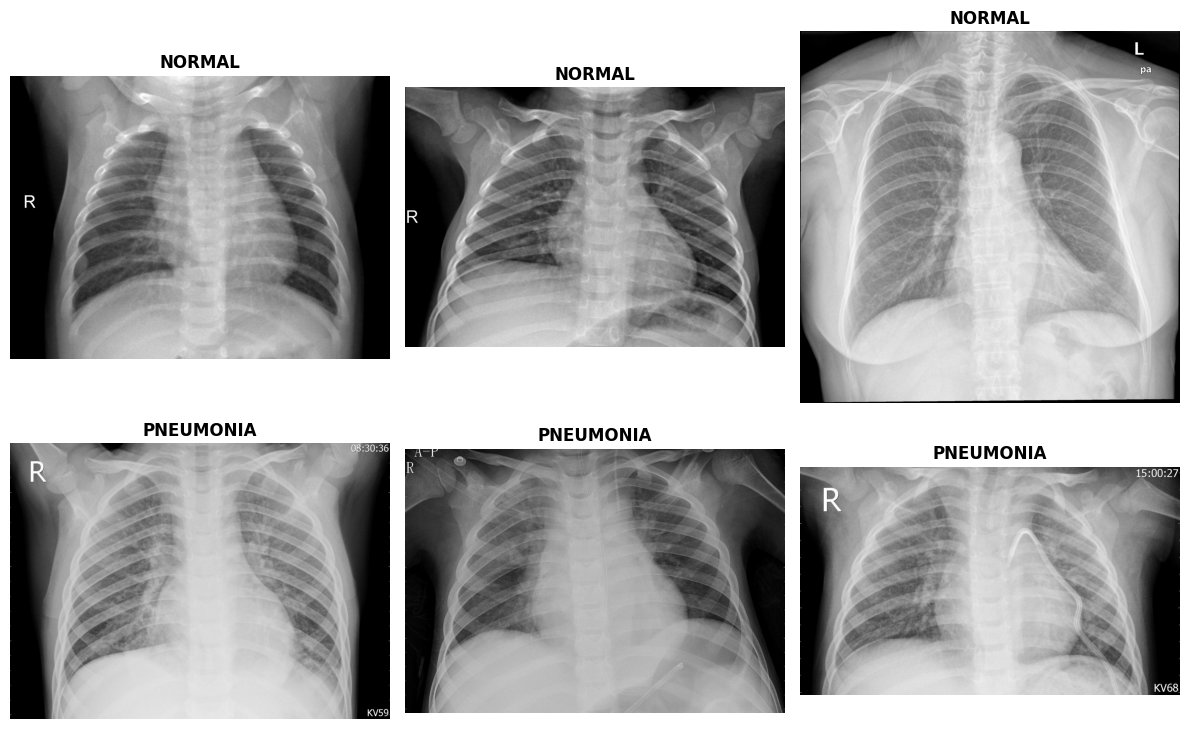

In [ ]:
def show_samples(dataset, n=6):
    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    axes = axes.flatten()
    class_names = ['NORMAL', 'PNEUMONIA']

    # samples from both classes
    normal_indices = [i for i, label in enumerate(dataset.labels) if label == 0]
    pneumonia_indices = [i for i, label in enumerate(dataset.labels) if label == 1]

    # Show 3 NORMAL + 3 PNEUMONIA
    indices = normal_indices[:3] + pneumonia_indices[:3]

    for idx, i in enumerate(indices):
        img = Image.open(dataset.images[i])
        label = dataset.labels[i]
        axes[idx].imshow(img, cmap='gray')
        axes[idx].set_title(class_names[label], fontsize=12, fontweight='bold')
        axes[idx].axis('off')

    plt.tight_layout()
    plt.show()

show_samples(train_dataset)

In [ ]:
class PneumoniaDetector(nn.Module):
    def __init__(self, num_classes=2, pretrained=True):
        super(PneumoniaDetector, self).__init__()
        self.backbone = models.resnet18(pretrained=pretrained)
        num_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(num_features, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)

# Initializing model
model = PneumoniaDetector(num_classes=2, pretrained=True)
model = model.to(device)

print(f" Model ready")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 126MB/s]


✓ Model ready
Parameters: 11,177,538


In [ ]:
NUM_EPOCHS = 10
LEARNING_RATE = 0.001

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)

print(f"Training ready")
print(f"Epochs: {NUM_EPOCHS}, LR: {LEARNING_RATE}")

✓ Training config ready
Epochs: 10, LR: 0.001


#Training Functions

In [ ]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(dataloader, desc="Training")
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        pbar.set_postfix({'loss': f'{loss.item():.4f}', 'acc': f'{100*correct/total:.2f}%'})

    return running_loss / total, 100 * correct / total

def validate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        pbar = tqdm(dataloader, desc="Validation")
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            pbar.set_postfix({'loss': f'{loss.item():.4f}', 'acc': f'{100*correct/total:.2f}%'})

    return running_loss / total, 100 * correct / total

print("Training functions ready")

Training functions ready


#Train Model

In [ ]:
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0.0

print("="*60)
print("STARTING TRAINING")
print("="*60)

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    print("-"*60)

    # Train
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)

    # Validate
    val_loss, val_acc = validate(model, val_loader, criterion, device)

    # Update scheduler
    scheduler.step(val_acc)

    # Save history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    # Print summary
    print(f"\nEpoch {epoch+1} Summary:")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        print(f" New best! Val Acc: {val_acc:.2f}%")

print("\n" + "="*60)
print(f"TRAINING COMPLETE! Best Val Acc: {best_val_acc:.2f}%")
print("="*60)

STARTING TRAINING

Epoch 1/10
------------------------------------------------------------


Validation: 100%|██████████| 1/1 [00:00<00:00,  2.86it/s, loss=2.4970, acc=50.00%]



Epoch 1 Summary:
Train Loss: 0.1564 | Train Acc: 94.17%
Val Loss: 2.4970 | Val Acc: 50.00%
 New best! Val Acc: 50.00%

Epoch 2/10
------------------------------------------------------------


Validation: 100%|██████████| 1/1 [00:00<00:00,  3.14it/s, loss=0.2442, acc=87.50%]



Epoch 2 Summary:
Train Loss: 0.1032 | Train Acc: 96.01%
Val Loss: 0.2442 | Val Acc: 87.50%
 New best! Val Acc: 87.50%

Epoch 3/10
------------------------------------------------------------


...


Epoch 8 Summary:
Train Loss: 0.0588 | Train Acc: 97.85%
Val Loss: 0.4032 | Val Acc: 75.00%

Epoch 9/10
------------------------------------------------------------


Validation: 100%|██████████| 1/1 [00:00<00:00,  3.07it/s, loss=1.4703, acc=62.50%]



Epoch 9 Summary:
Train Loss: 0.0509 | Train Acc: 98.10%
Val Loss: 1.4703 | Val Acc: 62.50%

Epoch 10/10
------------------------------------------------------------


Validation: 100%|██████████| 1/1 [00:00<00:00,  3.10it/s, loss=0.3737, acc=87.50%]


Epoch 10 Summary:
Train Loss: 0.0492 | Train Acc: 98.12%
Val Loss: 0.3737 | Val Acc: 87.50%

TRAINING COMPLETE! Best Val Acc: 100.00%


#Result

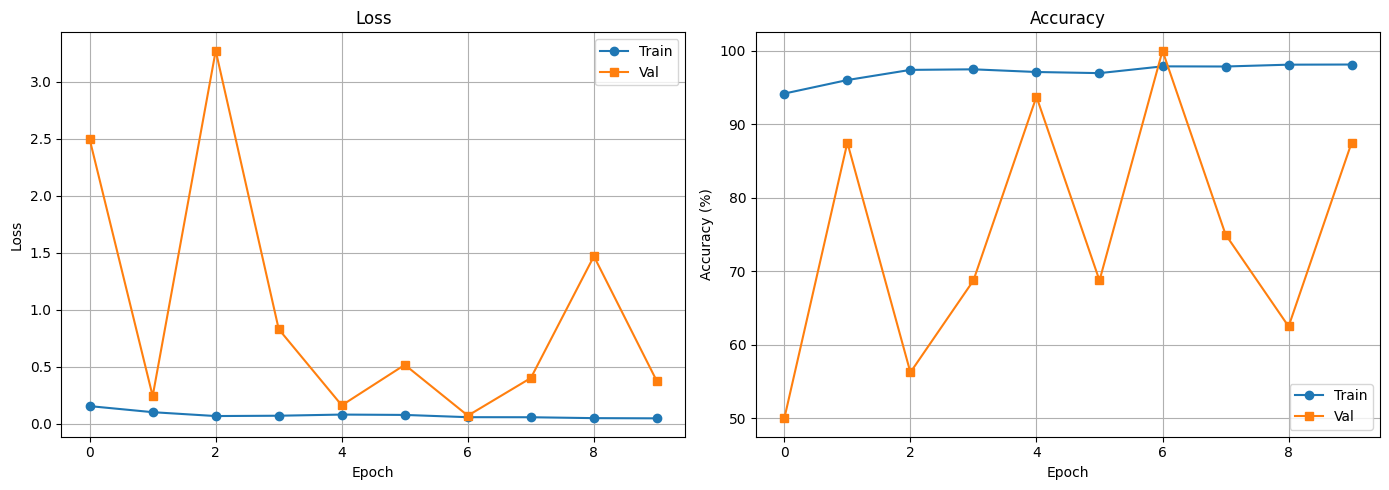

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss
ax1.plot(history['train_loss'], label='Train', marker='o')
ax1.plot(history['val_loss'], label='Val', marker='s')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss')
ax1.legend()
ax1.grid(True)

# Accuracy
ax2.plot(history['train_acc'], label='Train', marker='o')
ax2.plot(history['val_acc'], label='Val', marker='s')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
#  results
print("="*60)
print("TRAINING RESULTS - DETAILED")
print("="*60)

print("\nEpoch-wise Results:")
print("-"*60)
print(f"{'Epoch':<8} {'Train Loss':<12} {'Train Acc':<12} {'Val Loss':<12} {'Val Acc':<12}")
print("-"*60)

for epoch in range(len(history['train_loss'])):
    print(f"{epoch+1:<8} {history['train_loss'][epoch]:<12.4f} {history['train_acc'][epoch]:<12.2f} {history['val_loss'][epoch]:<12.4f} {history['val_acc'][epoch]:<12.2f}")

print("-"*60)
print(f"\nBest Validation Accuracy: {best_val_acc:.2f}%")
print(f"Final Train Accuracy: {history['train_acc'][-1]:.2f}%")
print(f"Final Train Loss: {history['train_loss'][-1]:.4f}")
print(f"Final Val Accuracy: {history['val_acc'][-1]:.2f}%")
print(f"Final Val Loss: {history['val_loss'][-1]:.4f}")
print("="*60)

TRAINING RESULTS - DETAILED

Epoch-wise Results:
------------------------------------------------------------
Epoch    Train Loss   Train Acc    Val Loss     Val Acc     
------------------------------------------------------------
1        0.1564       94.17        2.4970       50.00       
2        0.1032       96.01        0.2442       87.50       
3        0.0693       97.39        3.2726       56.25       
4        0.0721       97.47        0.8307       68.75       
5        0.0822       97.11        0.1632       93.75       
6        0.0791       96.95        0.5186       68.75       
7        0.0593       97.87        0.0728       100.00      
8        0.0588       97.85        0.4032       75.00       
9        0.0509       98.10        1.4703       62.50       
10       0.0492       98.12        0.3737       87.50       
------------------------------------------------------------

Best Validation Accuracy: 100.00%
Final Train Accuracy: 98.12%
Final Train Loss: 0.0492
Final Va

In [ ]:
# Create save directory
SAVE_DIR = Path('/content/drive/MyDrive/pneumonia_models')
SAVE_DIR.mkdir(parents=True, exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Save best model
best_model_path = SAVE_DIR / 'best_model.pth'
torch.save(model.state_dict(), best_model_path)
print(f" Model saved: {best_model_path}")

# Save checkpoint
checkpoint = {
    'epoch': NUM_EPOCHS,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'best_val_acc': best_val_acc,
    'history': history
}
checkpoint_path = SAVE_DIR / f'checkpoint_{timestamp}.pth'
torch.save(checkpoint, checkpoint_path)
print(f" Checkpoint saved: {checkpoint_path}")

# Save metadata
metadata = {
    'timestamp': timestamp,
    'best_val_acc': float(best_val_acc),
    'final_train_acc': float(history['train_acc'][-1]),
    'final_val_acc': float(history['val_acc'][-1]),
    'num_epochs': NUM_EPOCHS,
    'class_names': ['NORMAL', 'PNEUMONIA']
}
metadata_path = SAVE_DIR / f'metadata_{timestamp}.json'
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=4)
print(f" Metadata saved: {metadata_path}")

print("\n ALL FILES SAVED TO GOOGLE DRIVE!")

 Model saved: /content/drive/MyDrive/pneumonia_models/best_model.pth
 Checkpoint saved: /content/drive/MyDrive/pneumonia_models/checkpoint_20260214_042132.pth
 Metadata saved: /content/drive/MyDrive/pneumonia_models/metadata_20260214_042132.json

 ALL FILES SAVED TO GOOGLE DRIVE!


In [ ]:
test_loss, test_acc = validate(model, test_loader, criterion, device)

print("\n" + "="*60)
print("TEST SET RESULTS")
print("="*60)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.2f}%")
print("="*60)

Validation: 100%|██████████| 20/20 [00:09<00:00,  2.08it/s, loss=0.0007, acc=76.60%]


TEST SET RESULTS
Test Loss: 1.0155
Test Accuracy: 76.60%


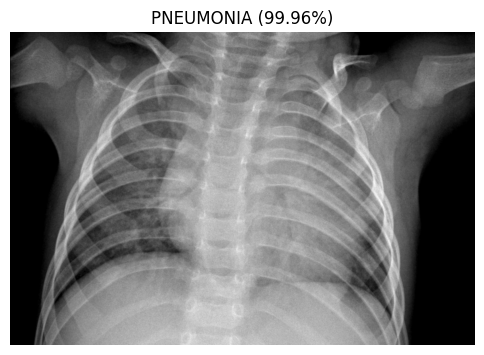

Prediction: PNEUMONIA
Confidence: 0.9996
Probabilities: {'NORMAL': 0.0003834043745882809, 'PNEUMONIA': 0.9996166229248047}


In [ ]:
def predict_image(model, image_path, transform, device):
    model.eval()
    image = Image.open(image_path).convert('RGB')
    image_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(image_tensor)
        probabilities = torch.softmax(outputs, dim=1)
        confidence, predicted = torch.max(probabilities, 1)

    class_names = ['NORMAL', 'PNEUMONIA']
    return {
        'prediction': class_names[predicted.item()],
        'confidence': confidence.item(),
        'probabilities': {
            'NORMAL': probabilities[0][0].item(),
            'PNEUMONIA': probabilities[0][1].item()
        }
    }

# Test
test_img = test_dataset.images[0]
result = predict_image(model, test_img, val_transform, device)

# Show
fig, ax = plt.subplots(figsize=(6, 6))
img = Image.open(test_img)
ax.imshow(img, cmap='gray')
ax.set_title(f"{result['prediction']} ({result['confidence']:.2%})")
ax.axis('off')
plt.show()

print(f"Prediction: {result['prediction']}")
print(f"Confidence: {result['confidence']:.4f}")
print(f"Probabilities: {result['probabilities']}")

In [ ]:
# Colab mein yeh run karo - file download hogi
from google.colab import files
files.download('/content/drive/MyDrive/pneumonia_models/best_model.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>